# Telco Customer Churn — Exploratory Data Analysis

> **Author:** Data Science Portfolio Project  
> **Dataset:** Synthetic Telco Churn (10,000 customers, 21 features)  
> **Goal:** Understand the drivers of customer churn to inform the prediction model.

---

## Business Context

Customer churn — when a subscriber cancels their service — is one of the **most costly problems** in the telecom industry.

| Metric | Value |
|--------|-------|
| Average cost to acquire a new customer | **\$300–\$500** |
| Average cost to retain an existing one | **\$50–\$100** |
| Industry average annual churn rate | **~26%** |

A model that predicts churners *before* they leave allows the retention team to intervene with targeted offers — potentially **saving hundreds of dollars per customer**.

**This notebook** covers:
1. Dataset overview
2. Univariate analysis
3. Bivariate analysis (churn drivers)
4. Correlation analysis
5. Key insights

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data_generation import generate_telco_data
from src.visualization import (
    plot_churn_distribution,
    plot_churn_rate_by_feature,
    plot_tenure_vs_churn,
    plot_correlation_heatmap,
)

plt.rcParams['figure.dpi'] = 120
sns.set_palette('husl')

DATA_PATH = Path('../data/raw/telco_churn.csv')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Dataset

In [2]:
# Load or generate the dataset
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded from {DATA_PATH}')
else:
    print('Generating synthetic dataset...')
    df = generate_telco_data(n_samples=10000, random_state=42)
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(DATA_PATH, index=False)
    print(f'Saved to {DATA_PATH}')

print(f'\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

Loaded from ../data/raw/telco_churn.csv

Shape: 10,000 rows × 21 columns
Memory usage: 10581.0 KB


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST-00001,Male,0,Yes,No,5,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),32.59,161.69,Yes
1,CUST-00002,Female,0,Yes,No,17,Yes,No,DSL,Yes,...,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),90.67,1543.61,No
2,CUST-00003,Female,0,Yes,No,3,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Mailed check,87.56,270.19,Yes
3,CUST-00004,Male,0,No,No,29,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),79.27,2294.11,No
4,CUST-00005,Male,0,No,No,19,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),83.77,1594.41,No


## 2. Dataset Overview

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        10000 non-null  object 
 1   gender            10000 non-null  object 
 2   SeniorCitizen     10000 non-null  int64  
 3   Partner           10000 non-null  object 
 4   Dependents        10000 non-null  object 
 5   tenure            10000 non-null  int64  
 6   PhoneService      10000 non-null  object 
 7   MultipleLines     10000 non-null  object 
 8   InternetService   10000 non-null  object 
 9   OnlineSecurity    10000 non-null  object 
 10  OnlineBackup      10000 non-null  object 
 11  DeviceProtection  10000 non-null  object 
 12  TechSupport       10000 non-null  object 
 13  StreamingTV       10000 non-null  object 
 14  StreamingMovies   10000 non-null  object 
 15  Contract          10000 non-null  object 
 16  PaperlessBilling  10000 non-null  object 

In [5]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found — clean dataset!')
else:
    print(missing_df)

No missing values found — clean dataset!


In [6]:
# Numeric summary statistics
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,10000.00,10000.00,10000.00
mean,25.04,71.33,1792.08
std,18.06,31.35,1612.85
min,1.00,18.00,7.57
25%,11.00,40.86,592.81
50%,20.00,76.22,1315.76
75%,37.00,97.46,2463.30
max,72.00,120.00,8642.53


In [7]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()
churn_rate = (df['Churn'] == 'Yes').mean()
print(f'Churned customers  : {churn_counts["Yes"]:,} ({churn_rate:.1%})')
print(f'Retained customers : {churn_counts["No"]:,} ({1 - churn_rate:.1%})')
print(f'Class imbalance ratio: 1 : {churn_counts["No"]/churn_counts["Yes"]:.1f}')

Churned customers  : 2,919 (29.2%)
Retained customers : 7,081 (70.8%)
Class imbalance ratio: 1 : 2.4


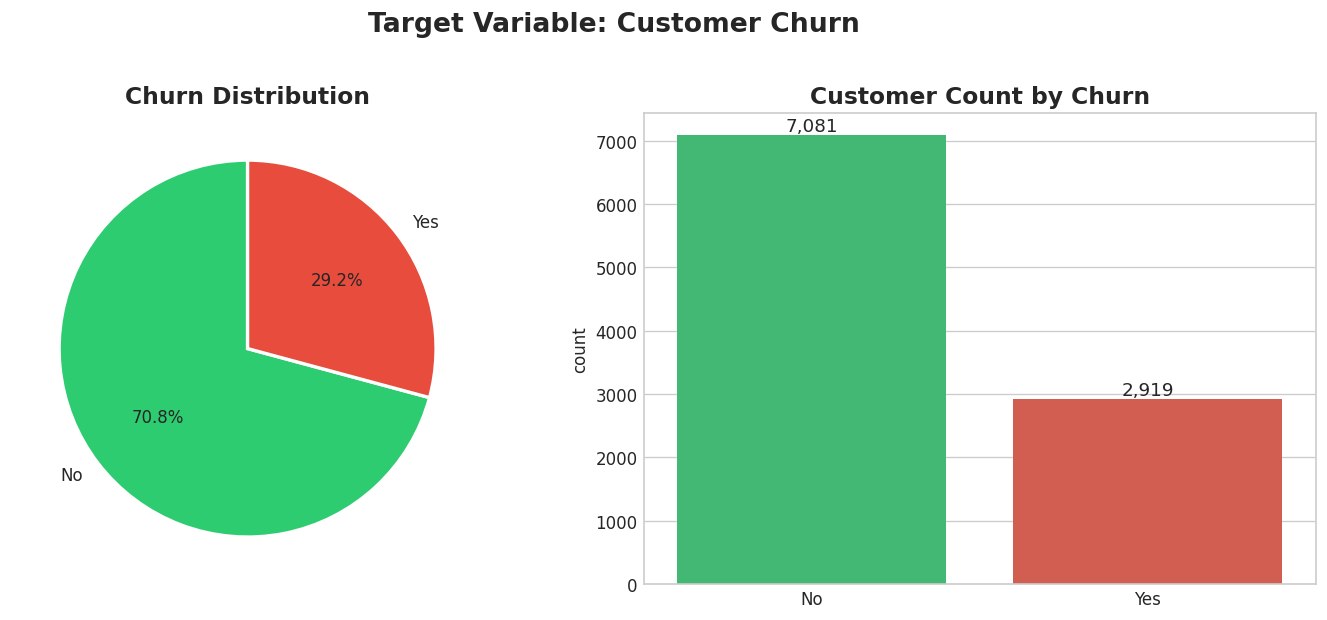

In [8]:
fig = plot_churn_distribution(df, save=True)
plt.show()

## 3. Univariate Analysis

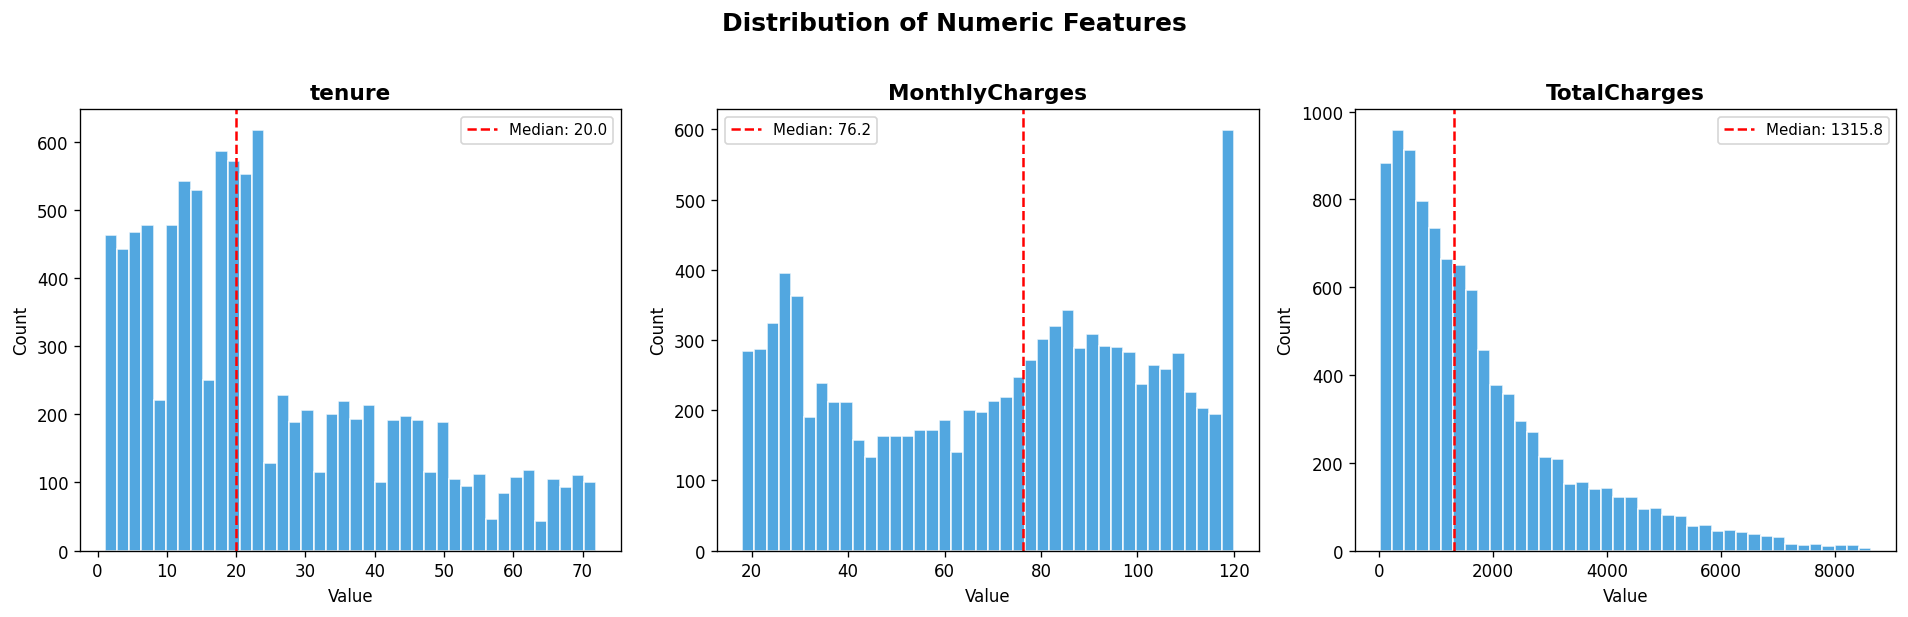

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.hist(df[col], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.axvline(df[col].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Numeric Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/univariate_numeric.png', bbox_inches='tight', dpi=150)
plt.show()

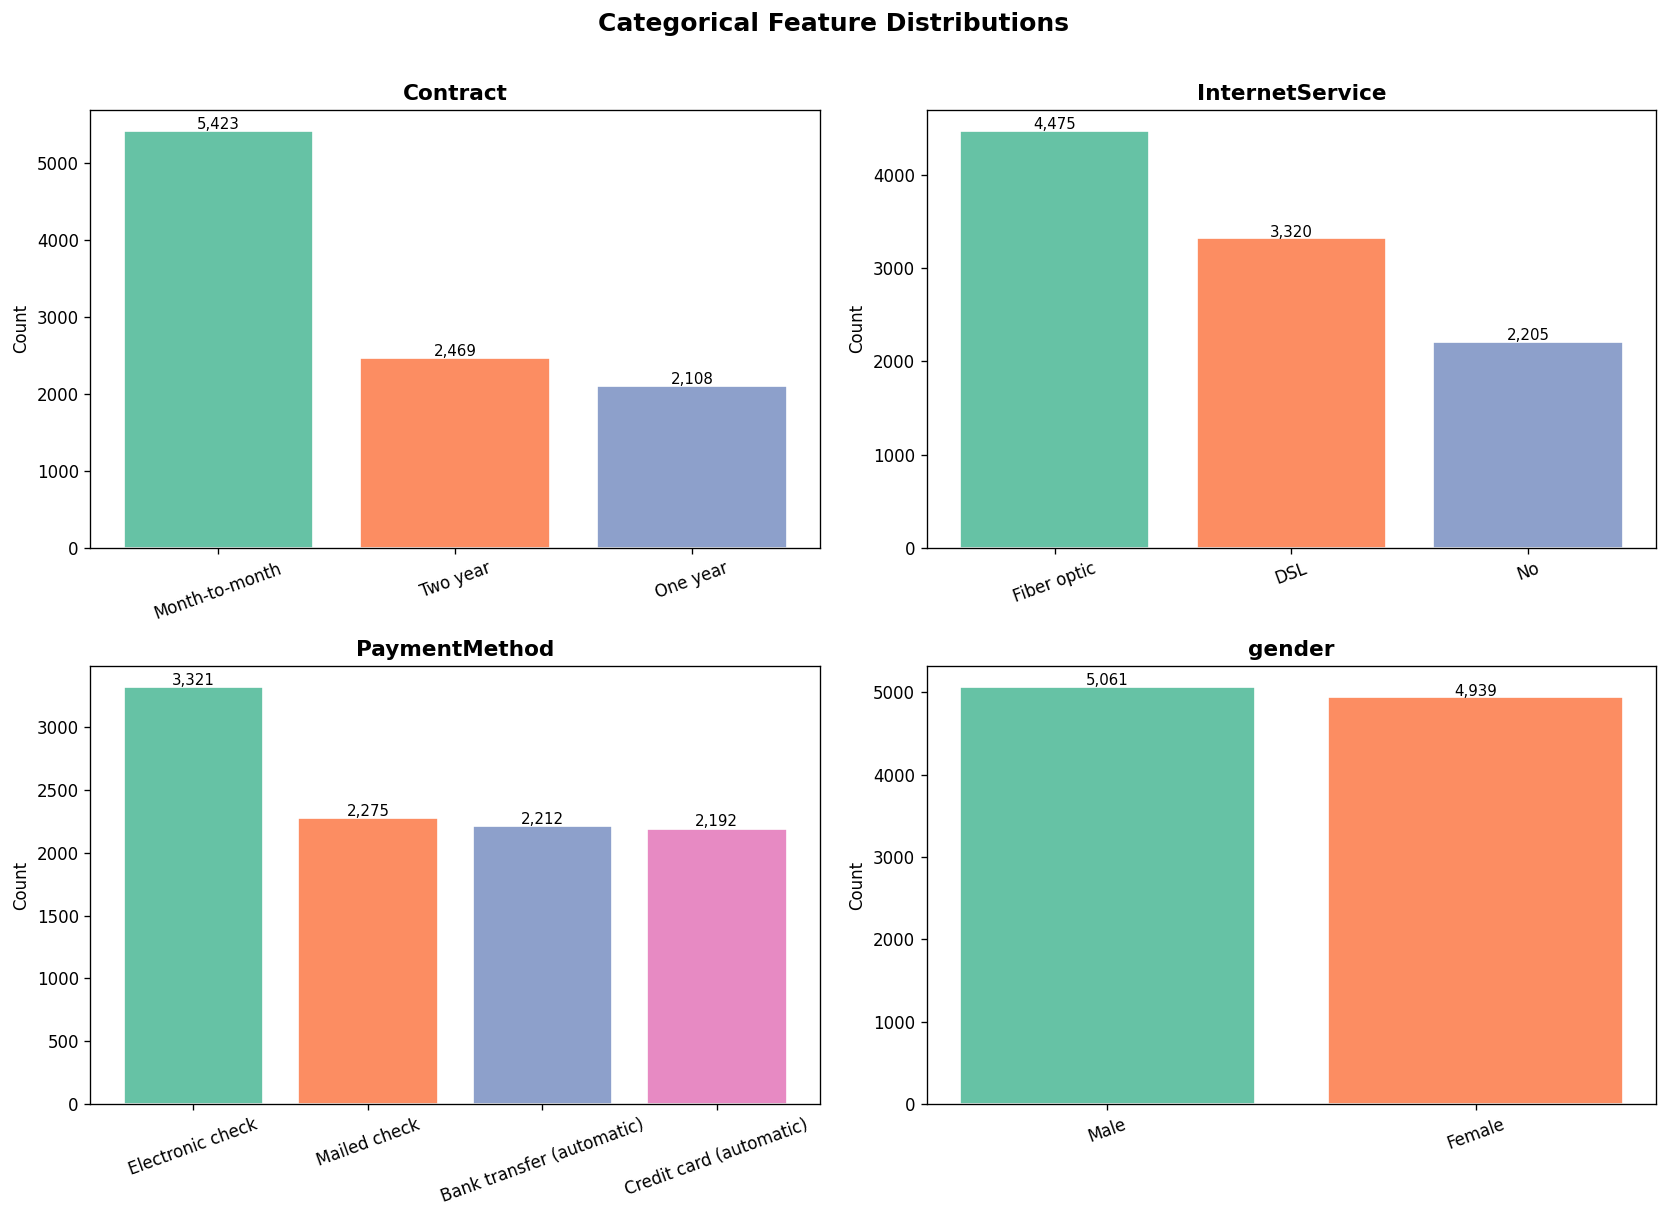

In [10]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_features):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)), edgecolor='white')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylabel('Count')
    for i, (idx, val) in enumerate(counts.items()):
        ax.text(i, val + 20, f'{val:,}', ha='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/univariate_categorical.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Bivariate Analysis — What Drives Churn?

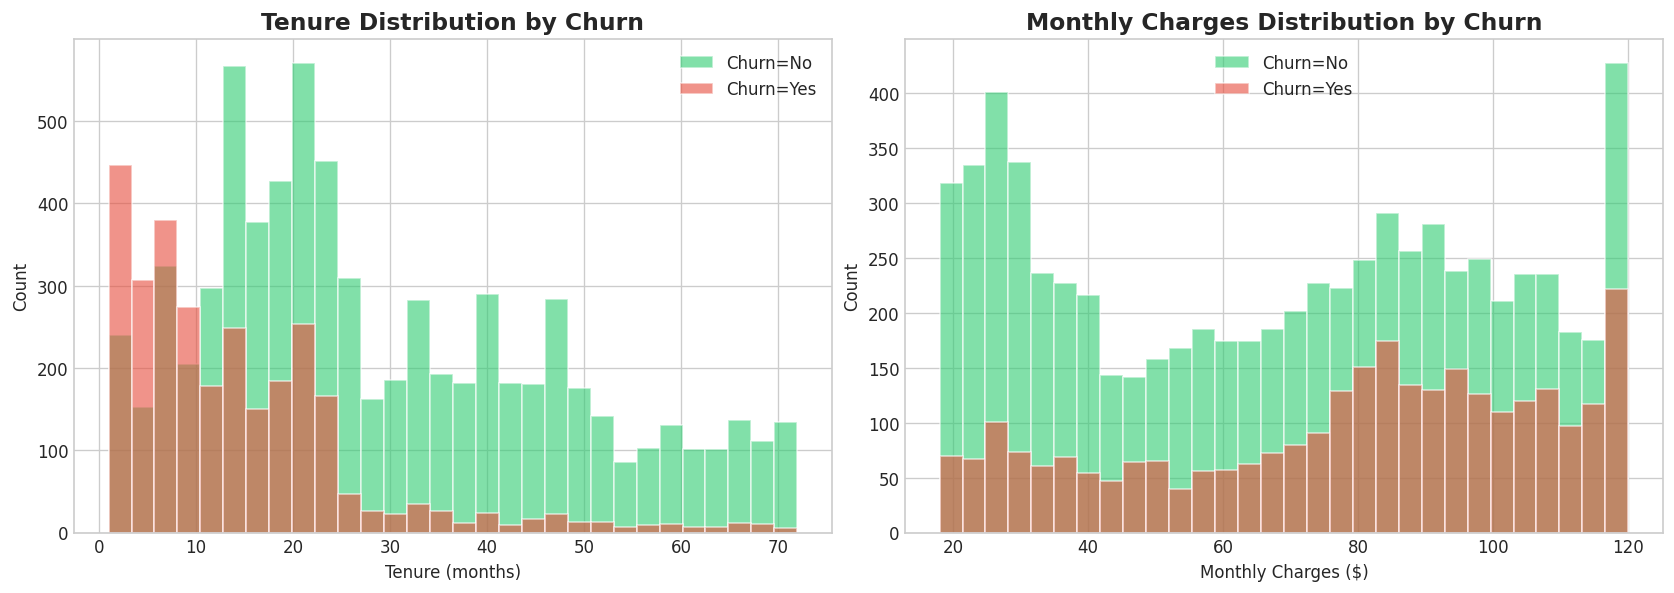

In [11]:
# Tenure and Monthly Charges distribution by churn status
fig = plot_tenure_vs_churn(df, save=True)
plt.show()

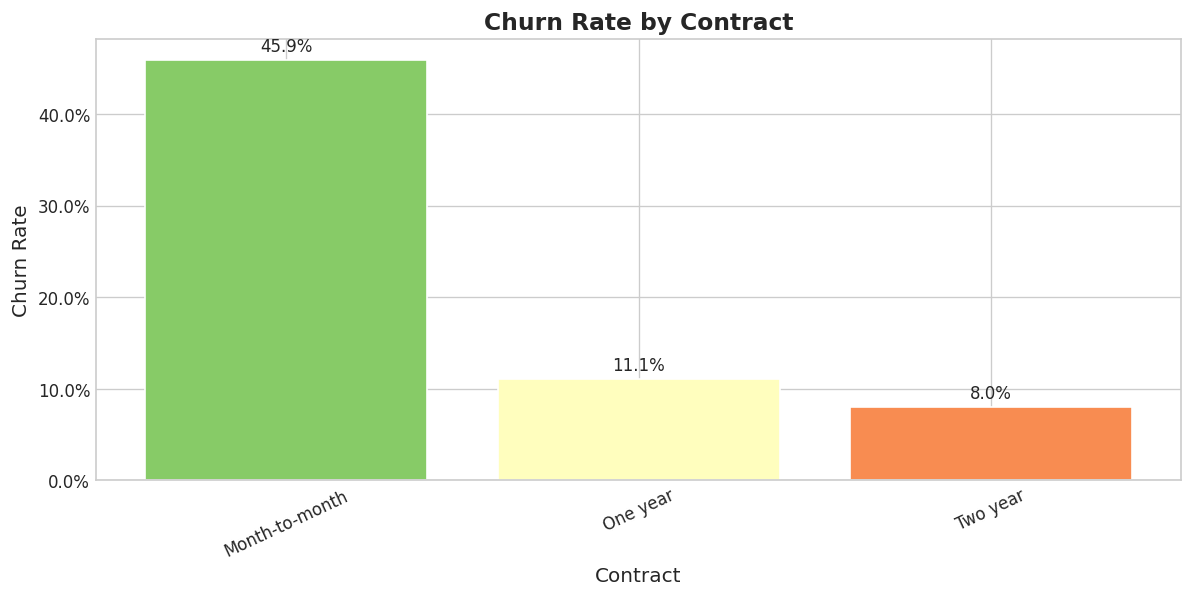

In [12]:
# Churn rate by Contract type — the strongest predictor
fig = plot_churn_rate_by_feature(df, 'Contract', save=True)
plt.show()

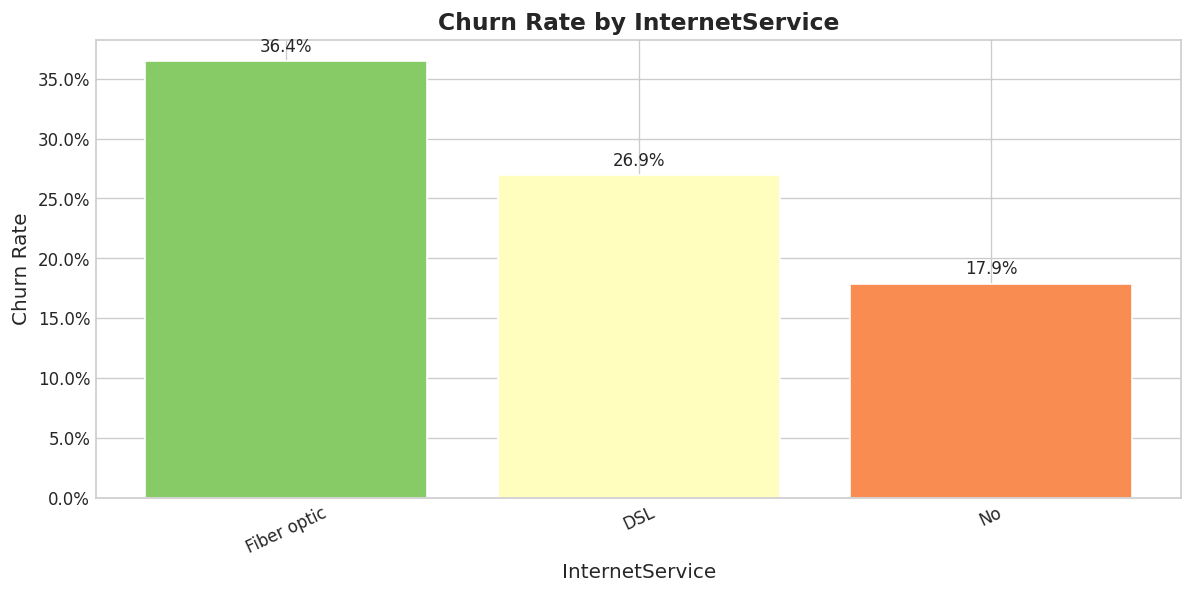

In [13]:
# Churn rate by Internet Service type
fig = plot_churn_rate_by_feature(df, 'InternetService', save=True)
plt.show()

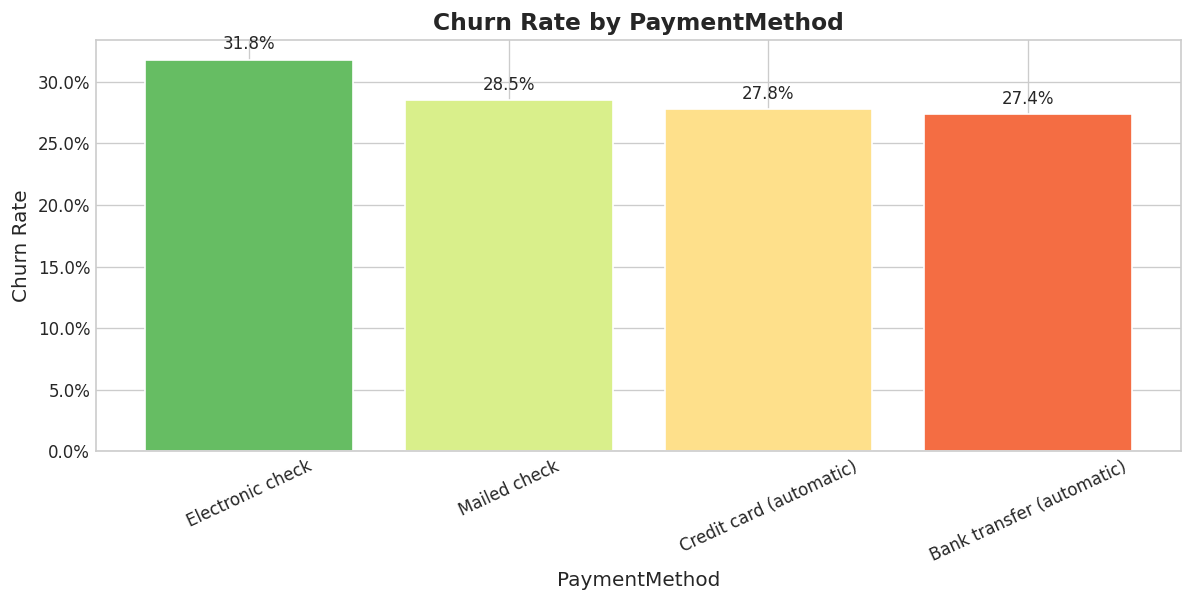

In [14]:
# Churn rate by Payment Method
fig = plot_churn_rate_by_feature(df, 'PaymentMethod', save=True)
plt.show()

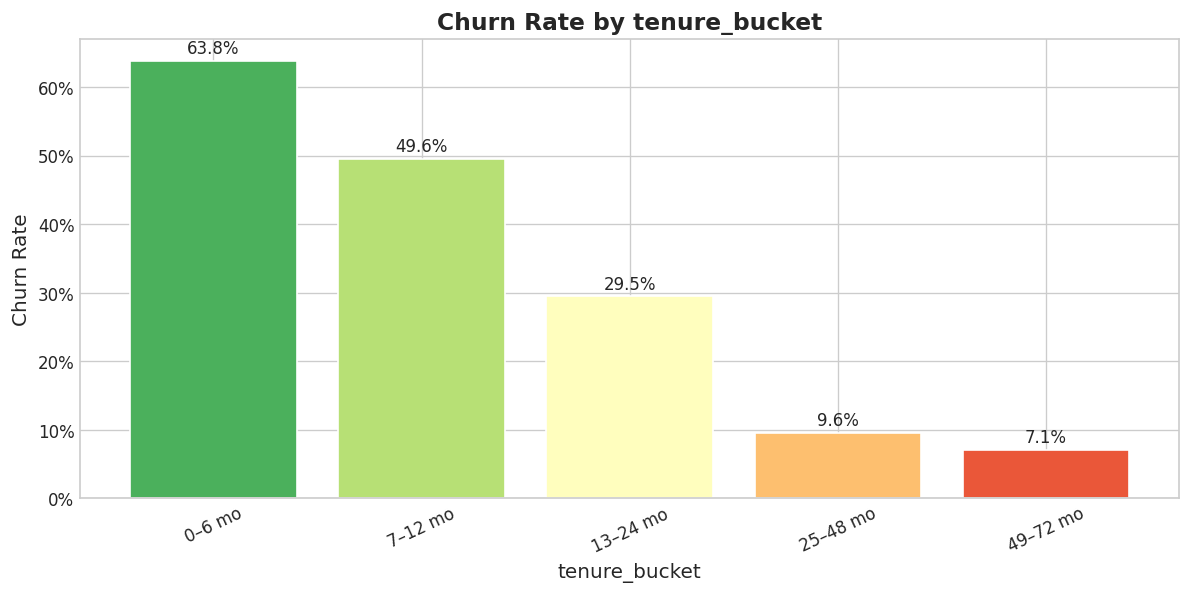

In [15]:
# Churn rate by tenure bucket
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 73],
    labels=['0–6 mo', '7–12 mo', '13–24 mo', '25–48 mo', '49–72 mo']
)
fig = plot_churn_rate_by_feature(df, 'tenure_bucket', save=True)
plt.show()
df.drop(columns=['tenure_bucket'], inplace=True)

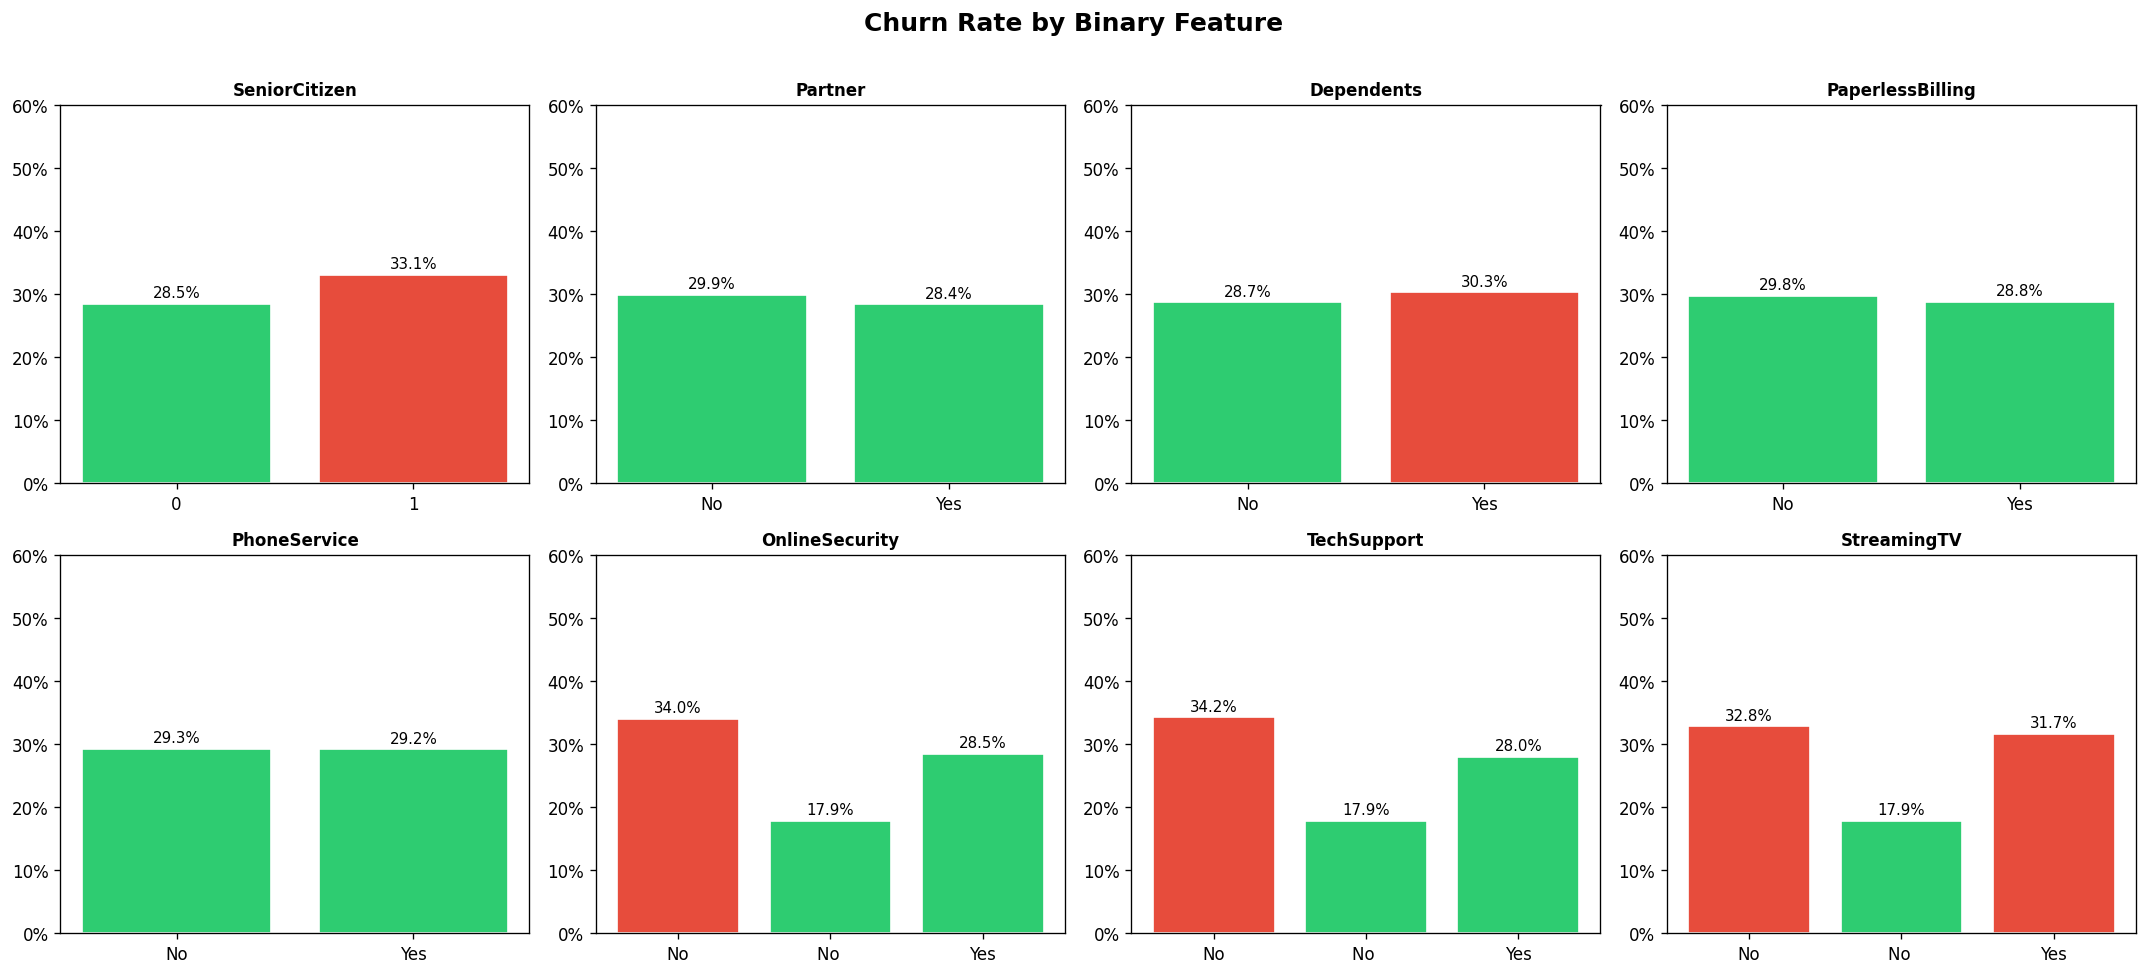

In [16]:
# Multi-feature churn rate overview
binary_features = [
    'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling',
    'PhoneService', 'OnlineSecurity', 'TechSupport', 'StreamingTV'
]

churn_rates = {}
for feat in binary_features:
    grp = df.groupby(feat)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rates[feat] = grp

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, feat in zip(axes.flatten(), binary_features):
    data = df.groupby(feat)['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
    data.columns = [feat, 'Churn Rate']
    colors = ['#e74c3c' if r > 0.30 else '#2ecc71' for r in data['Churn Rate']]
    ax.bar(data[feat].astype(str), data['Churn Rate'], color=colors, edgecolor='white')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 0.60)
    for i, val in enumerate(data['Churn Rate']):
        ax.text(i, val + 0.01, f'{val:.1%}', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Binary Feature', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_binary_features.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Correlation Analysis

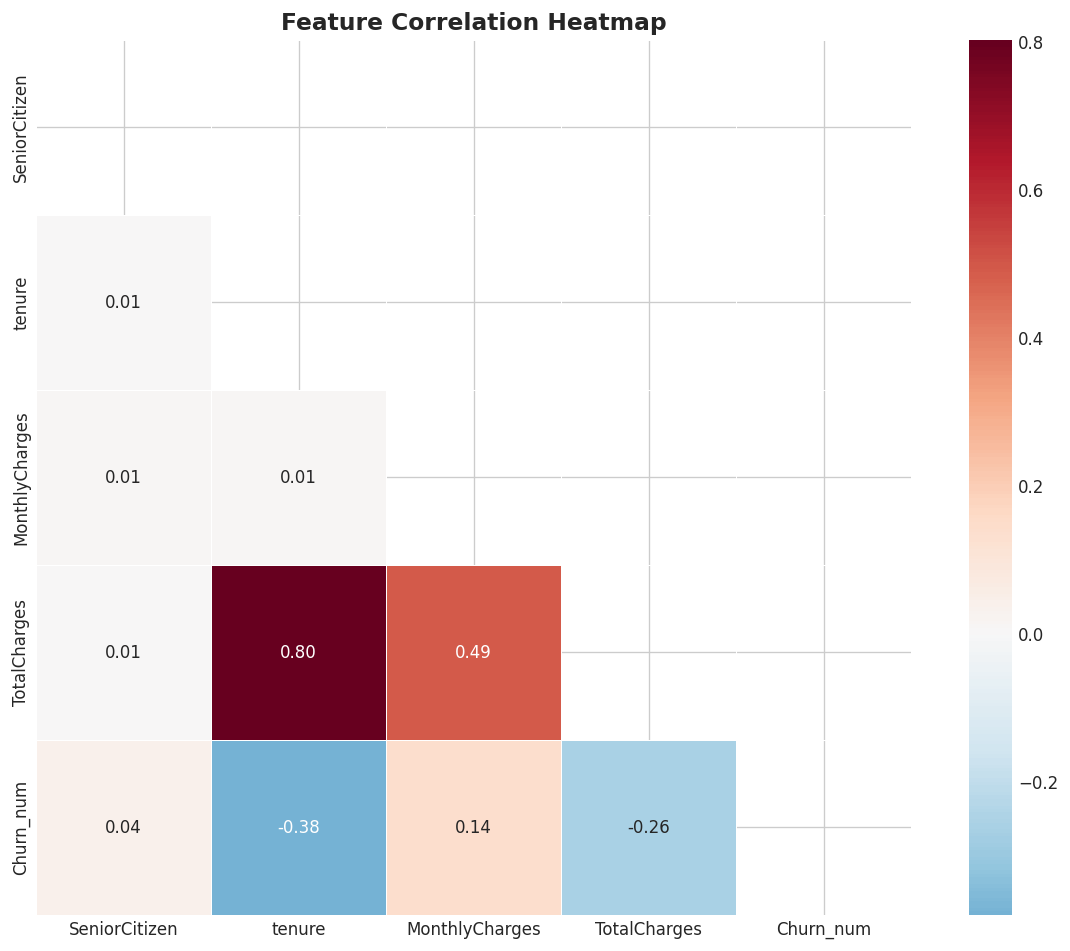

In [17]:
# Add numeric target for correlation
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

fig = plot_correlation_heatmap(df_corr, save=True)
plt.show()

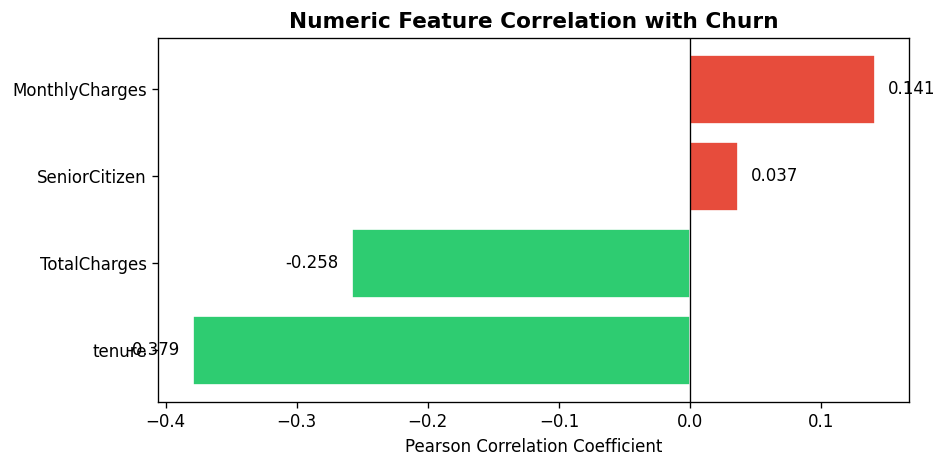

In [18]:
# Correlation of each numeric feature with churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']
corr_with_churn = df_corr[numeric_cols].corr()['Churn_num'].drop('Churn_num').sort_values()

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in corr_with_churn]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
ax.set_title('Numeric Feature Correlation with Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
for i, val in enumerate(corr_with_churn):
    ax.text(val + (0.01 if val >= 0 else -0.01), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_with_churn.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Key Insights

After this exploratory analysis, here are the **5 most important findings**:

---

### Insight 1 — Contract Type is the Dominant Predictor
**Month-to-month customers churn at ~45%**, compared to ~11% for one-year and ~3% for two-year contracts. Contract type alone is a powerful retention lever — customers locked into annual/biennial agreements are dramatically more loyal.

### Insight 2 — Early Tenure is the Highest-Risk Window
Customers in their **first 6 months churn at over 50%**. After 24 months, churn drops below 10%. The first two years are critical for building customer loyalty through excellent onboarding and proactive support.

### Insight 3 — Fiber Optic Users Have Paradoxically Higher Churn
Despite being the premium offering, **Fiber Optic internet service shows ~35–40% churn** vs ~20% for DSL. This likely reflects price sensitivity (higher monthly charges) and unmet expectations about service quality.

### Insight 4 — Security & Support Add-ons Are Retention Tools
Customers **without OnlineSecurity or TechSupport** churn at nearly double the rate of those who have them. These services may act as switching cost anchors — or simply indicate less engaged, lower-value customers.

### Insight 5 — Electronic Check Payment is a Churn Signal
Customers paying by **electronic check churn at ~35%**, compared to ~15% for automatic payment methods. Manual payment methods may indicate lower commitment and are worth targeting for auto-pay migration campaigns.

---

**→ Next:** `02_Modeling.ipynb` — Feature Engineering, Model Training, and Evaluation